In [3]:



def _current_ping_config(self):
        """Return the live UI-config snapshot used to build the TX ping waveform."""
        return {
            "chirp_frames": int(self._ping_config_value("chirp_frames", self.PING_TX_DEFAULTS["chirp_frames"])),
            "bandwidth_hz": float(self._ping_config_value("bandwidth_hz", self.PING_TX_DEFAULTS["bandwidth_hz"])),
            "pings_per_256": int(self._ping_config_value("pings_per_256", self.PING_TX_DEFAULTS["pings_per_256"])),
            "tx_gain_db": float(self._ping_config_value("tx_gain_db", self.PING_TX_DEFAULTS["tx_gain_db"])),
        }

    def _build_ping_waveform(self, config=None):
        """Build one 256-sample cyclic TX buffer with the current UI-config values."""
        cfg = self._current_ping_config() if config is None else config
        chirp_frames = int(cfg["chirp_frames"])
        bw_hz = float(cfg["bandwidth_hz"])
        pings_per_256 = int(cfg["pings_per_256"])
        fs_hz = 40e6

        pings_per_256 = max(1, min(pings_per_256, CHUNK_SAMPLES))
        burst_length = CHUNK_SAMPLES // pings_per_256
        chirp_frames = max(1, min(chirp_frames, burst_length))

        t = np.arange(chirp_frames, dtype=np.float64) / fs_hz
        chirp_duration = chirp_frames / fs_hz
        f_start = -bw_hz / 2.0
        f_end = bw_hz / 2.0
        k = (f_end - f_start) / chirp_duration
        phase = 2.0 * np.pi * (f_start * t + 0.5 * k * (t ** 2))
        active_chirp = np.exp(1j * phase).astype(np.complex64)

        zero_samples = max(0, burst_length - chirp_frames)
        single_burst = np.concatenate((active_chirp, np.zeros(zero_samples, dtype=np.complex64)))

        # Match periodic_ping.py: repeat the chirp-plus-silence block.
        waveform_256 = np.tile(single_burst, pings_per_256)[:CHUNK_SAMPLES]
        if waveform_256.size != CHUNK_SAMPLES:
            raise ValueError(f"TX waveform must contain exactly {CHUNK_SAMPLES} samples")

        waveform_scaled = waveform_256 * AMPLITUDE_TARGET
        waveform_int16 = np.real(waveform_scaled).astype(np.int16) + 1j * np.imag(waveform_scaled).astype(np.int16)
        return waveform_int16

    def _matched_filter(self, iq):
        """Return normalized chirp correlation and local peak indices."""
        if self._tx_waveform is None:
            return np.zeros(len(iq), dtype=np.float32), []
        config = self._current_ping_config()
        pings_per_256 = max(1, min(config["pings_per_256"], CHUNK_SAMPLES))
        burst_length = CHUNK_SAMPLES // pings_per_256
        chirp_frames = max(1, min(config["chirp_frames"], burst_length))
        reference = np.asarray(self._tx_waveform[:chirp_frames], dtype=np.complex64)
        received = np.asarray(iq, dtype=np.complex64)
        if reference.size == 0 or received.size == 0:
            return np.zeros(received.size, dtype=np.float32), []
        correlation = np.convolve(received, np.conj(reference[::-1]), mode="same")
        reference_energy = float(np.vdot(reference, reference).real)
        received_energy = np.convolve(np.abs(received) ** 2, np.ones(burst_length), mode="same")
        denominator = np.sqrt(np.maximum(reference_energy * received_energy, 1e-12))
        score = (np.abs(correlation) / denominator).astype(np.float32)
        plotted_correlation = np.abs(correlation).astype(np.float32);

        threshold = 0.35
        spacing = max(1, reference.size // 2)
        local_maximum = np.ones(score.size, dtype=bool)
        if score.size > 2:
            local_maximum[1:-1] = (score[1:-1] >= score[:-2]) & (score[1:-1] >= score[2:])
        candidates = np.flatnonzero((score >= threshold) & local_maximum)
        peaks = []
        for index in candidates[np.argsort(score[candidates])[::-1]]:
            if all(abs(int(index) - peak) >= spacing for peak in peaks):
                peaks.append(int(index))
        peaks.sort()
        return plotted_correlation, peaks

IndentationError: unindent does not match any outer indentation level (<string>, line 10)

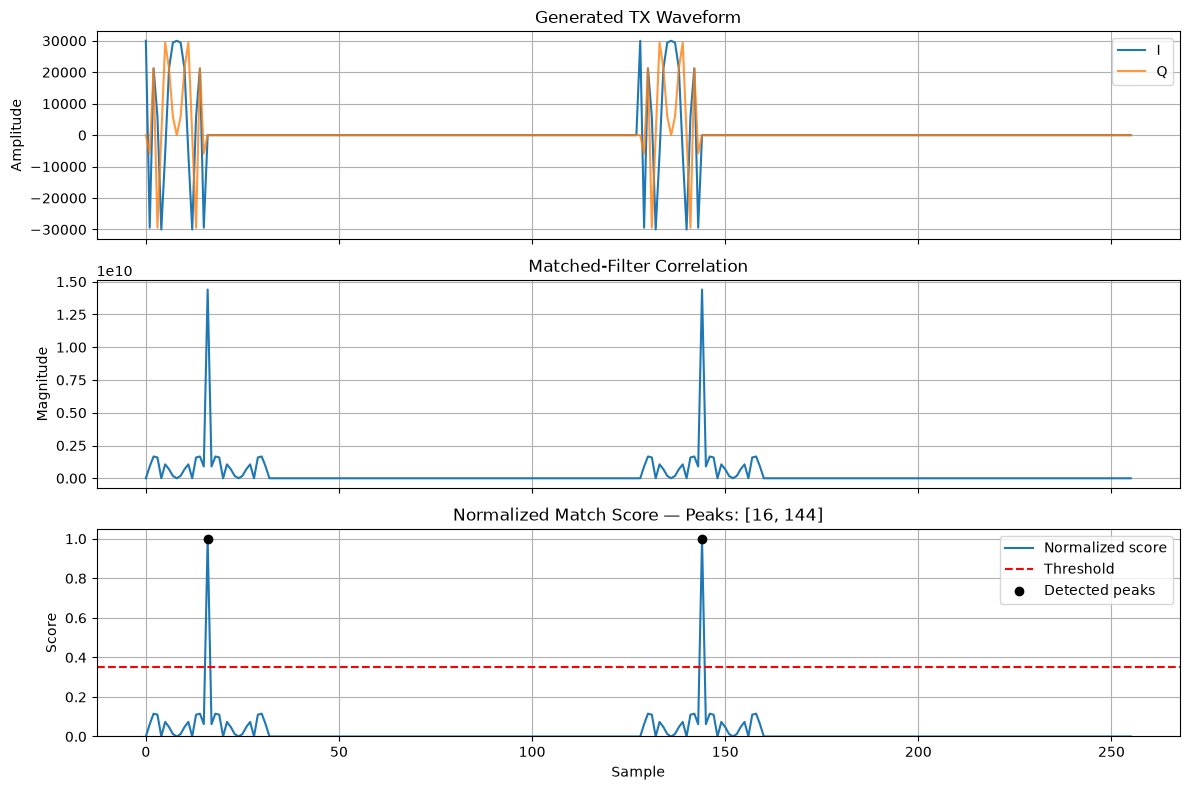

In [3]:
import numpy as np

import matplotlib.pyplot as plt

CHUNK_SAMPLES = 256
AMPLITUDE_TARGET = 30000.0
FS_HZ = 40e6


def build_ping_waveform(
    chirp_frames=16,
    bandwidth_hz=40e6,
    pings_per_256=2,
):
    pings_per_256 = max(1, min(int(pings_per_256), CHUNK_SAMPLES))
    burst_length = CHUNK_SAMPLES // pings_per_256
    chirp_frames = max(1, min(int(chirp_frames), burst_length))

    t = np.arange(chirp_frames, dtype=np.float64) / FS_HZ
    chirp_duration = chirp_frames / FS_HZ
    f_start = -bandwidth_hz / 2.0
    f_end = bandwidth_hz / 2.0
    k = (f_end - f_start) / chirp_duration

    phase = 2 * np.pi * (f_start * t + 0.5 * k * t**2)
    chirp = np.exp(1j * phase).astype(np.complex64)

    silence = np.zeros(burst_length - chirp_frames, dtype=np.complex64)
    burst = np.concatenate((chirp, silence))
    waveform = np.tile(burst, pings_per_256)[:CHUNK_SAMPLES]

    return (
        np.real(waveform * AMPLITUDE_TARGET).astype(np.int16)
        + 1j * np.imag(waveform * AMPLITUDE_TARGET).astype(np.int16)
    )


def matched_filter(iq, chirp_frames=32, pings_per_256=4, threshold=0.35):
    burst_length = CHUNK_SAMPLES // pings_per_256
    reference = iq[:chirp_frames].astype(np.complex64)
    received = iq.astype(np.complex64)

    correlation = np.convolve(
        received,
        np.conj(reference[::-1]),
        mode="same",
    )

    reference_energy = np.vdot(reference, reference).real
    received_energy = np.convolve(
        np.abs(received) ** 2,
        np.ones(burst_length),
        mode="same",
    )

    score = np.abs(correlation) / np.sqrt(
        np.maximum(reference_energy * received_energy, 1e-12)
    )

    local_maximum = np.ones(score.size, dtype=bool)
    if score.size > 2:
        local_maximum[1:-1] = (
            (score[1:-1] >= score[:-2])
            & (score[1:-1] >= score[2:])
        )

    candidates = np.flatnonzero((score >= threshold) & local_maximum)
    spacing = max(1, chirp_frames // 2)

    peaks = []
    for index in candidates[np.argsort(score[candidates])[::-1]]:
        if all(abs(int(index) - peak) >= spacing for peak in peaks):
            peaks.append(int(index))

    return np.abs(correlation), score, sorted(peaks)


waveform = build_ping_waveform()
correlation, score, peaks = matched_filter(waveform)

samples = np.arange(len(waveform))

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(samples, waveform.real, label="I")
axes[0].plot(samples, waveform.imag, label="Q", alpha=0.8)
axes[0].set_title("Generated TX Waveform")
axes[0].set_ylabel("Amplitude")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(samples, correlation)
axes[1].set_title("Matched-Filter Correlation")
axes[1].set_ylabel("Magnitude")
axes[1].grid(True)

axes[2].plot(samples, score, label="Normalized score")
axes[2].axhline(0.35, color="red", linestyle="--", label="Threshold")
axes[2].scatter(peaks, score[peaks], color="black", zorder=3, label="Detected peaks")
axes[2].set_title(f"Normalized Match Score — Peaks: {peaks}")
axes[2].set_xlabel("Sample")
axes[2].set_ylabel("Score")
axes[2].set_ylim(0, 1.05)
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()